<a href="https://colab.research.google.com/github/clock-s/Homeworks/blob/main/ICA_Homework_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
import kagglehub
import numpy as np
from numpy.linalg import eig
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math
!git clone https://github.com/clock-s/Homeworks

fatal: destination path 'Homeworks' already exists and is not an empty directory.


# 1º QUESTÃO

Describe your dataset and its features, identifying the number of observations N ,
number of predictor variables D, number of classes L and class-distribution (that
is, the number of observations for each of the classes).



---



Descreva seu dataset e suas features, identificando o número de obersvações N, o número de preditores D, o número de classes L e a distribuição dessas observações por classe.

In [92]:

# fetch dataset
white_wine = pd.read_csv('/content/Homeworks/winequality-white.csv', sep=';')
#white_wine = white_wine.drop(columns=['quality'])


red_wine = pd.read_csv('/content/Homeworks/winequality-red.csv', sep=';')
#red_wine = red_wine.drop(columns=['quality'])

wine_quality = pd.concat([white_wine, red_wine], ignore_index=True)

wine_quality.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [93]:
#print(wine_quality.data.features)
n_vinho_branco = white_wine[white_wine.columns[0]].count()
n_vinho_vermelho = red_wine[red_wine.columns[0]].count()
tamanho = wine_quality[wine_quality.columns[0]].count()
preditores = wine_quality.columns.size


print("Classes: Vinho branco e vinho vermelho")
print(f"Observações de vinho branco: {n_vinho_branco}")
print(f"Observações vinho vermelho: {n_vinho_vermelho}")
print(f"Quantidade total observações {tamanho}")
print(f"Preditores {white_wine.columns}")



Classes: Vinho branco e vinho vermelho
Observações de vinho branco: 4898
Observações vinho vermelho: 1599
Quantidade total observações 6497
Preditores Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


### Resposta:

Para esse dataset focado na qualidade do vinho, temos 2 classes, a de vinhos brancos e a de vinhos vermelhos. Para a quantidade de observações, foi conferido 4898 amostras de vinho branco e 1599 amostras de vinho vermelho totalizando 6497 amostras totais. Para a quantidade de preditores, temos 11 preditores de entrada e 1 de saída, sendo eles:


* Fixed Acidity
* Volatile Acidity
* Citric acid
* Residual sugar
* Chlorides
* Free sulfur dioxide
* Total sulfur dioxide
* Density
* pH
* Sulphates
* Alcohol
* Quality - Saída


# 2º QUESTÃO

Perform an unconditional mono-variate analysis of each of the D predictors. Specifically, you must plot their (unconditional) histograms and box-plots, calculate their
(unconditional) mean μd, standard deviation σd and skewness γd, with d = 1, . . . , D,
using all the N observations.



---



Faça uma analise monovariada incodicional para cada um dos D preditores. Você deve plotar o histograma, blox-plot, calcular a media, desvio padrão e "skewnes" para cada um dos preditores e usando as N observações.

In [94]:
total = wine_quality.to_numpy().transpose()

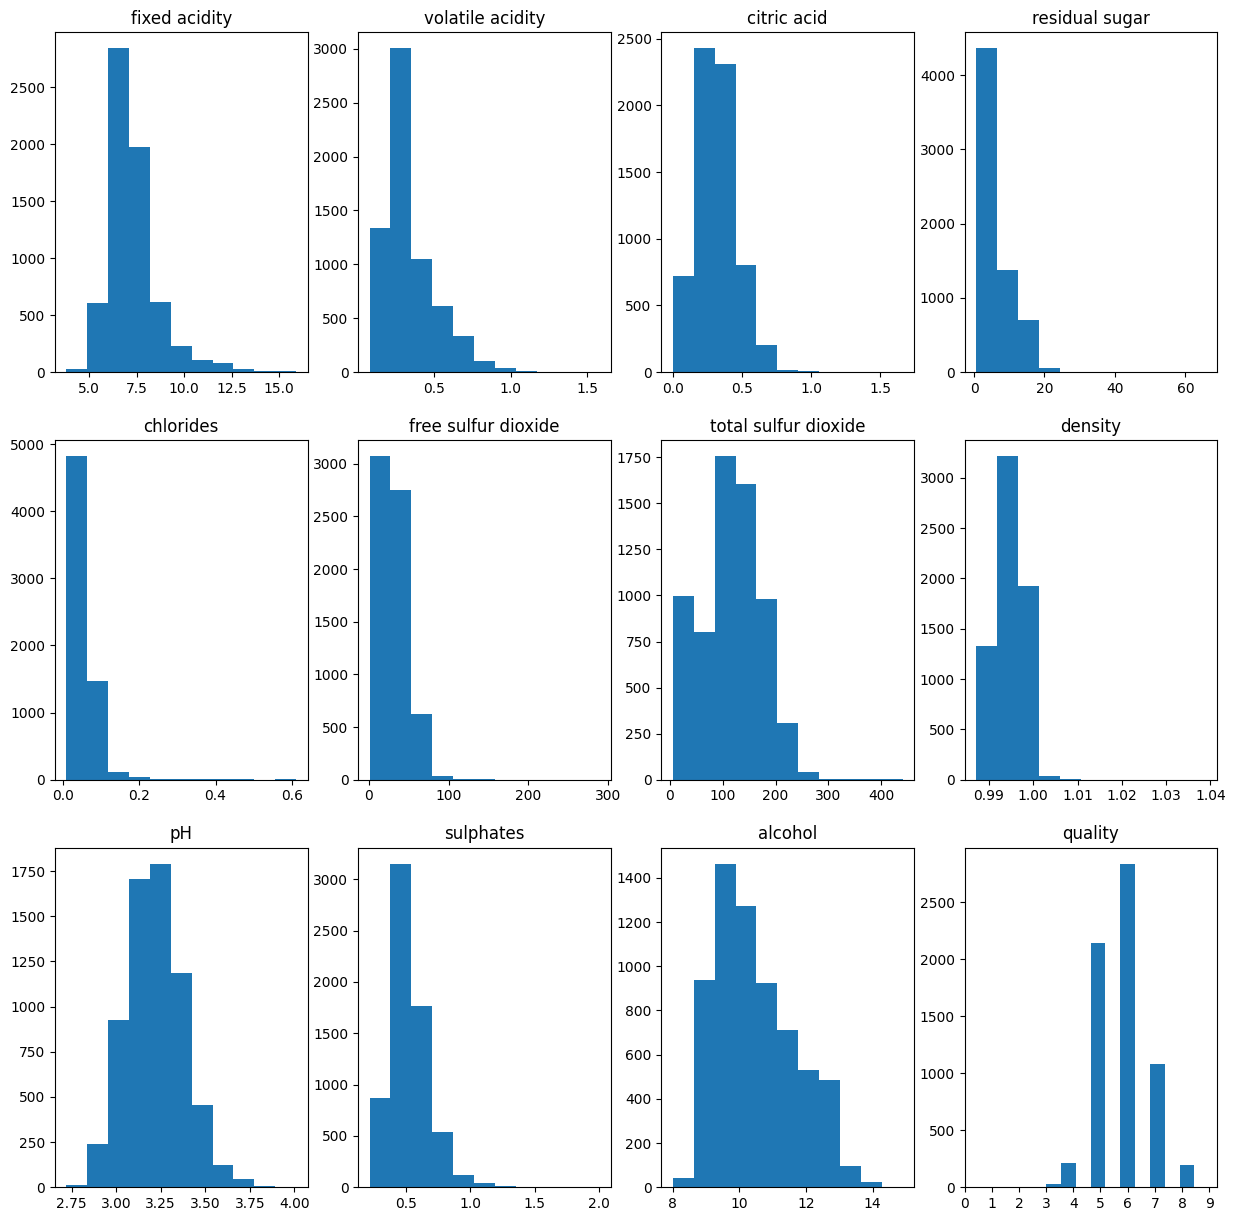

In [130]:
lines = 3
com = 4

fig, ax = plt.subplots(lines, com)
fig.set_figwidth(15)
fig.set_figheight(15)

for i in range(0, lines):
  for j in range(0, com):
    ax[i][j].hist(total[i*com + j], bins=11)
    ax[i][j].set_title(wine_quality.columns[i*com + j])

ax[lines-1][com-1].set_xticks(range(0, 10))

plt.show()

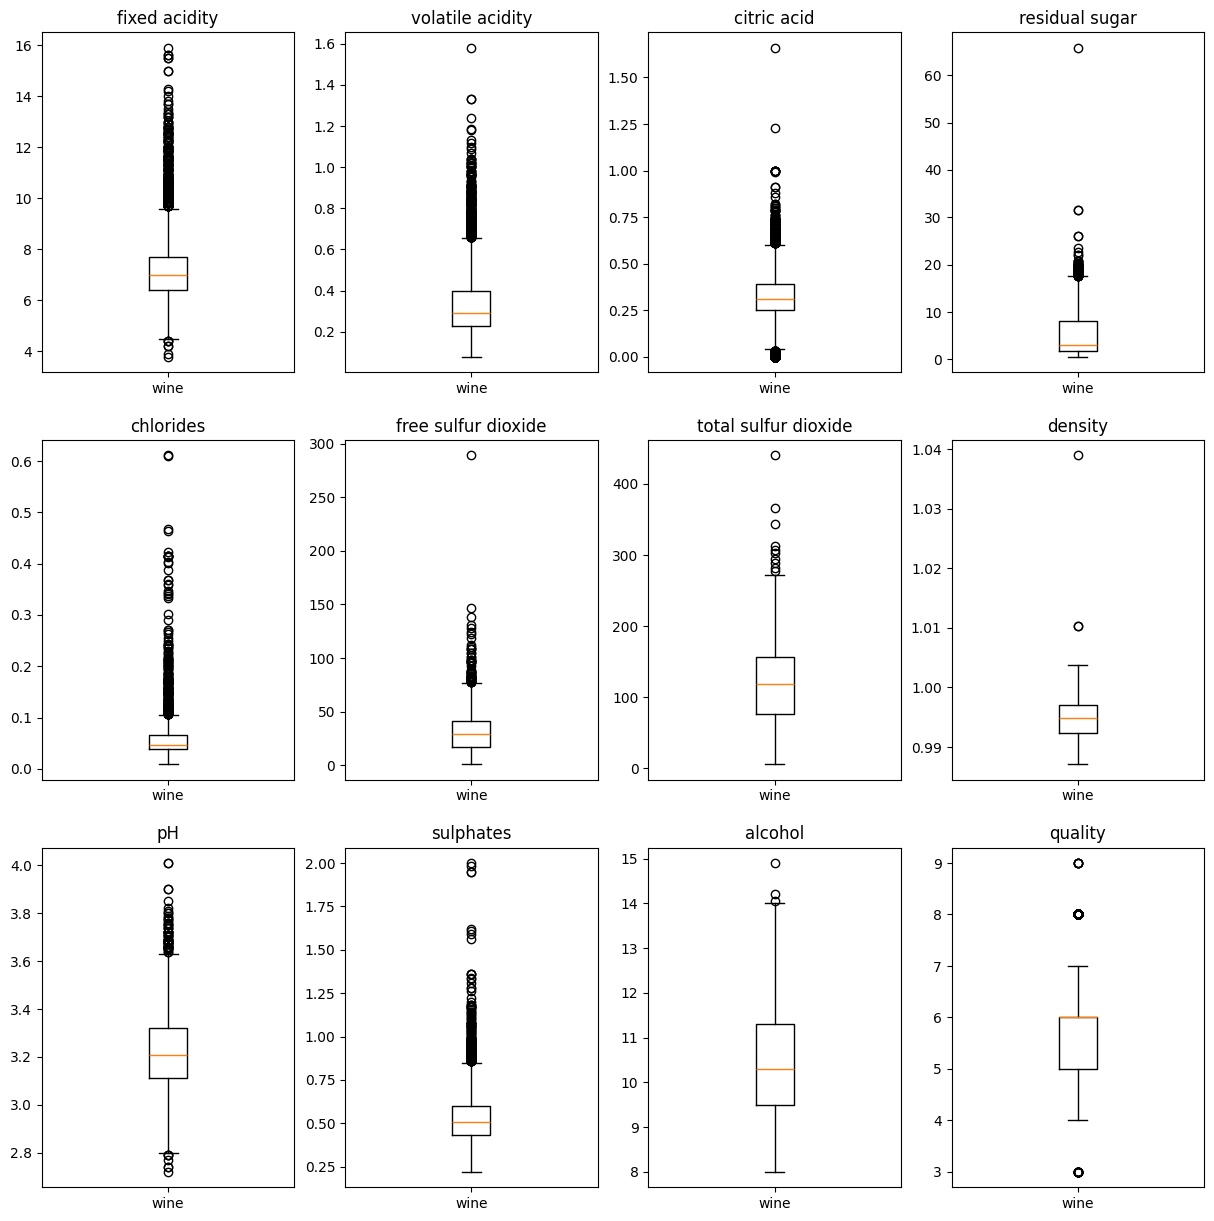

In [126]:
fig, ax = plt.subplots(lines, com)
fig.set_figwidth(15)
fig.set_figheight(15)

for i in range(0, lines):
  for j in range(0, com):
    ax[i][j].boxplot(total[i*com + j])
    ax[i][j].set_xticklabels(['wine'])
    ax[i][j].set_title(wine_quality.columns[i*com + j])

plt.show()

In [97]:
media_total = []
desvio_padrao_total = []

for i in range(0, preditores):
  media_total.append(total[i].mean())
  desvio_padrao_total.append(total[i].std())


In [98]:
for i in range(0, preditores):
  print(f"{wine_quality.columns[i]}:")
  print(f'\tMédia: {media_total[i]:.4f} | Desvio padrão: {desvio_padrao_total[i]:.4f}\n')

fixed acidity:
	Média: 7.2153 | Desvio padrão: 1.2963

volatile acidity:
	Média: 0.3397 | Desvio padrão: 0.1646

citric acid:
	Média: 0.3186 | Desvio padrão: 0.1453

residual sugar:
	Média: 5.4432 | Desvio padrão: 4.7574

chlorides:
	Média: 0.0560 | Desvio padrão: 0.0350

free sulfur dioxide:
	Média: 30.5253 | Desvio padrão: 17.7480

total sulfur dioxide:
	Média: 115.7446 | Desvio padrão: 56.5175

density:
	Média: 0.9947 | Desvio padrão: 0.0030

pH:
	Média: 3.2185 | Desvio padrão: 0.1608

sulphates:
	Média: 0.5313 | Desvio padrão: 0.1488

alcohol:
	Média: 10.4918 | Desvio padrão: 1.1926

quality:
	Média: 5.8184 | Desvio padrão: 0.8732



Para descobrir a skewnes foi utilizado a formula baseada em momento para descobrir a assimetria criada por Karl Paerson:

skewnes = $\frac{n}{(n-1)(n-2)} \sum_{i=1}^{n} (\frac{x_i - media}{dp})^3$

Em que $x_i$ é a amostra $i$ e $dp$ é o desvio padrão.



In [99]:
def skewness(array):
  media = array.mean()
  dp = array.std()
  n = array.size

  n_part = n / ((n-1)*(n-2))

  samples_part = np.sum(((array - media)/dp)**3)

  skew = n_part * samples_part

  return skew

In [100]:
skew = []
for i in range(0, preditores):
  skew.append(skewness(total[i]))

In [101]:
print("Skewness:")
for i in range(0, preditores):
  print(f'\t{wine_quality.columns[i]}: {skew[i]}')

Skewness:
	fixed acidity: 1.7236875891852408
	volatile acidity: 1.4954417903857984
	citric acid: 0.47183960463768954
	residual sugar: 1.4357357266521111
	chlorides: 5.401074661358807
	free sulfur dioxide: 1.2203478119884819
	total sulfur dioxide: -0.0011777501379667827
	density: 0.5037180219625511
	pH: 0.3869281269598238
	sulphates: 1.7976850297568903
	alcohol: 0.5658483647589875
	quality: 0.1896664810861025


# 3º QUESTÃO

Perform a class-conditional mono-variate analysis of each of the predictors. Again,
you must plot their (class-conditional) histograms and box-plots, calculate their
(class-conditional) mean μd|l, standard deviation σd|l and skewness γd|l , with d =
1, . . . , D, now using only the Nl observations of class l, for each the L classes.



---



Faça um analise condicional monovariada para cada pedritor. Novamente, você deve plotar histogramas e box-plots e calcular a media, desvio padrão e skewness. Faça isso para cada um dos preditores.

### Plot de ambos os tipos de vinhos

In [102]:
red = red_wine.to_numpy().transpose()
white = white_wine.to_numpy().transpose()

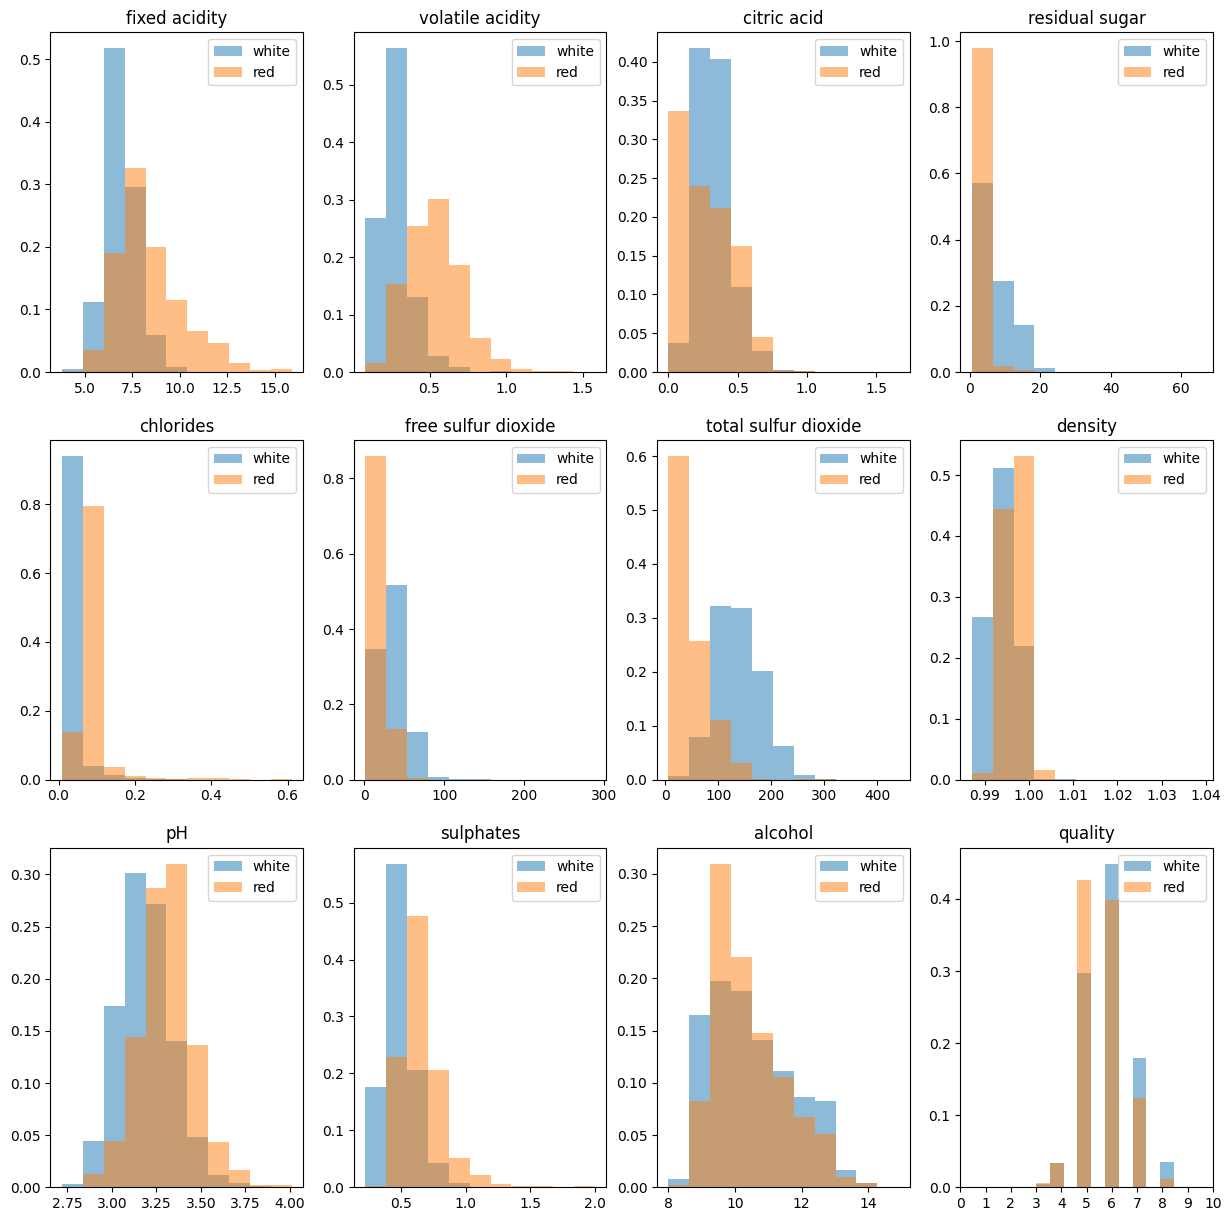

In [128]:
lines = 3
com = 4

fig, ax = plt.subplots(lines, com)
fig.set_figwidth(15)
fig.set_figheight(15)

for i in range(0, lines):
  for j in range(0, com):
    dados = np.concatenate((white[i*com + j], red[i*com + j]))
    bins = np.histogram_bin_edges(dados, bins=11)

    ax[i][j].hist(white[i*com + j], label="white", alpha=0.5, weights = np.ones(n_vinho_branco)/n_vinho_branco, bins=bins)
    ax[i][j].hist(red[i*com + j], label="red", alpha=0.5, weights = np.ones(n_vinho_vermelho)/n_vinho_vermelho, bins=bins)
    ax[i][j].legend(loc='upper right')
    ax[i][j].set_title(wine_quality.columns[i*com + j])


ax[lines-1][com-1].set_xticks(range(0, 11))

plt.show()

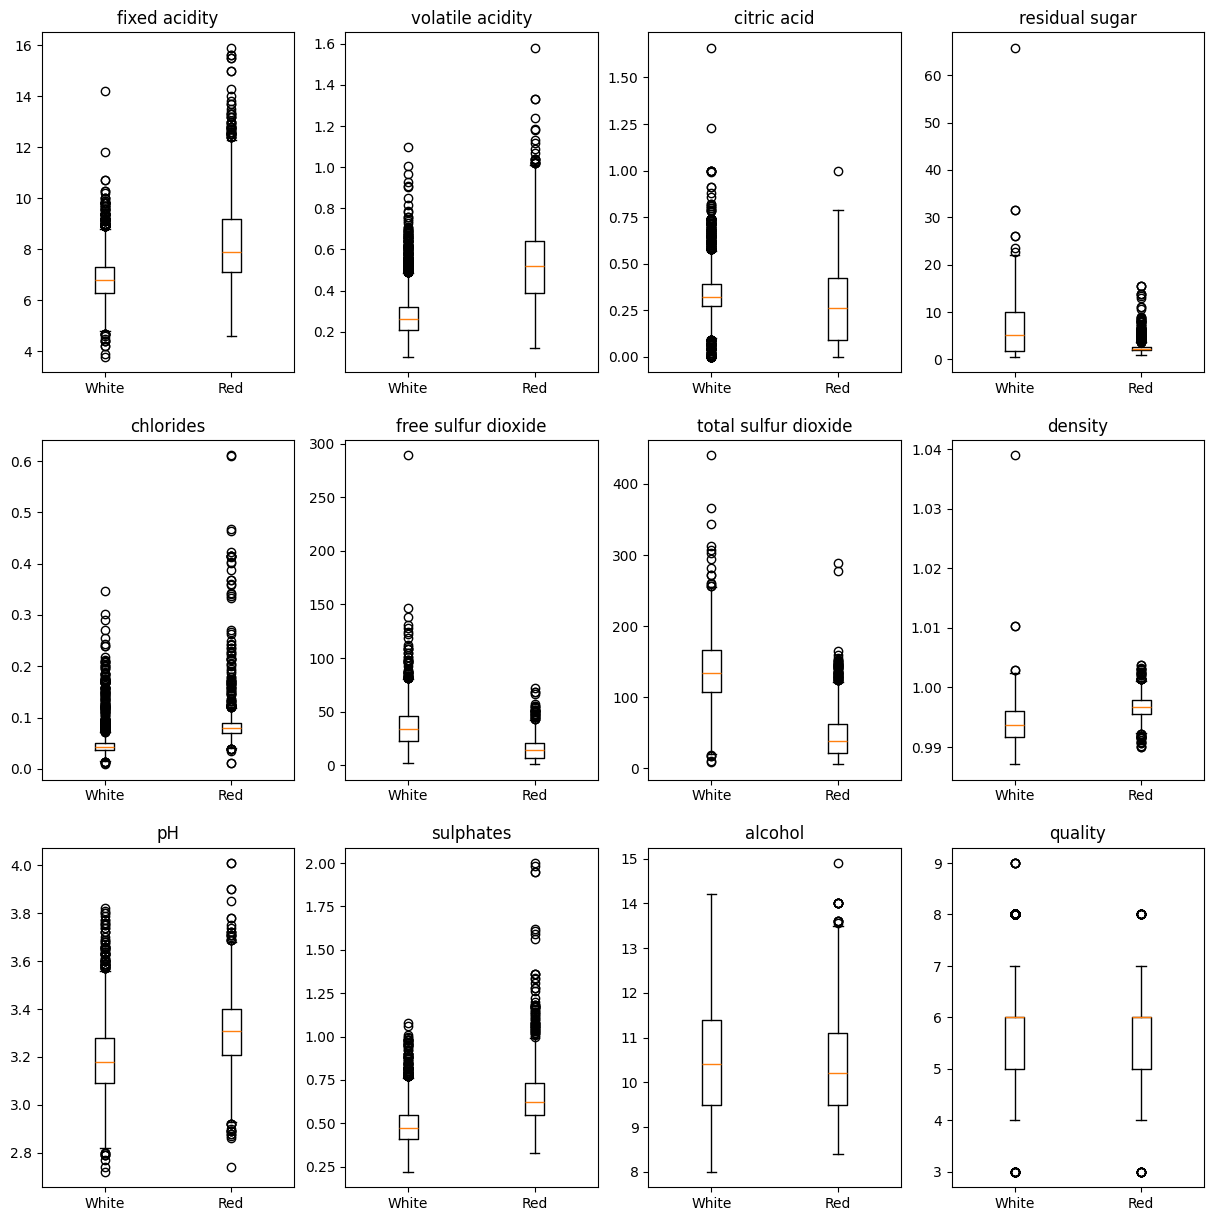

In [127]:
fig, ax = plt.subplots(lines, com)
fig.set_figwidth(15)
fig.set_figheight(15)

for i in range(0, lines):
  for j in range(0, com):
    plotter = {'White': white[i*com + j], "Red":red[i*com + j]}
    ax[i][j].boxplot(plotter.values())
    ax[i][j].set_xticklabels(plotter.keys())
    ax[i][j].set_title(wine_quality.columns[i*com + j])

plt.show()

### Analise para o vinhos vermelhos

In [105]:
media_red = []
desvio_padrao_red = []

for i in range(0, preditores):
  media_red.append(red[i].mean())
  desvio_padrao_red.append(red[i].std())


In [106]:
for i in range(0, preditores):
  print(f"{wine_quality.columns[i]}:")
  print(f'\tMédia: {media_red[i]:.4f} | Desvio padrão: {desvio_padrao_red[i]:.4f}\n')

fixed acidity:
	Média: 8.3196 | Desvio padrão: 1.7406

volatile acidity:
	Média: 0.5278 | Desvio padrão: 0.1790

citric acid:
	Média: 0.2710 | Desvio padrão: 0.1947

residual sugar:
	Média: 2.5388 | Desvio padrão: 1.4095

chlorides:
	Média: 0.0875 | Desvio padrão: 0.0471

free sulfur dioxide:
	Média: 15.8749 | Desvio padrão: 10.4569

total sulfur dioxide:
	Média: 46.4678 | Desvio padrão: 32.8850

density:
	Média: 0.9967 | Desvio padrão: 0.0019

pH:
	Média: 3.3111 | Desvio padrão: 0.1543

sulphates:
	Média: 0.6581 | Desvio padrão: 0.1695

alcohol:
	Média: 10.4230 | Desvio padrão: 1.0653

quality:
	Média: 5.6360 | Desvio padrão: 0.8073



In [107]:
skew = []
for i in range(0, preditores):
  skew.append(skewness(red[i]))

In [108]:
print("Skewness:")
for i in range(0, preditores):
  print(f'\t{wine_quality.columns[i]}: {skew[i]}')

Skewness:
	fixed acidity: 0.9836740682111809
	volatile acidity: 0.672223077042126
	citric acid: 0.3186361567307166
	residual sugar: 4.544918284836732
	chlorides: 5.685679395949467
	free sulfur dioxide: 1.251741351122899
	total sulfur dioxide: 1.516954068919025
	density: 0.07135458924566812
	pH: 0.19386533208894807
	sulphates: 2.430952440270784
	alcohol: 0.8616369703422533
	quality: 0.21800605198743928


### Para vinhos brancos

In [109]:
media_white = []
desvio_padrao_white = []

for i in range(0, preditores):
  media_white.append(white[i].mean())
  desvio_padrao_white.append(total[i].std())


In [110]:
for i in range(0, preditores):
  print(f"{wine_quality.columns[i]}:")
  print(f'\tMédia: {media_white[i]:.4f} | Desvio padrão: {desvio_padrao_white[i]:.4f}\n')

fixed acidity:
	Média: 6.8548 | Desvio padrão: 1.2963

volatile acidity:
	Média: 0.2782 | Desvio padrão: 0.1646

citric acid:
	Média: 0.3342 | Desvio padrão: 0.1453

residual sugar:
	Média: 6.3914 | Desvio padrão: 4.7574

chlorides:
	Média: 0.0458 | Desvio padrão: 0.0350

free sulfur dioxide:
	Média: 35.3081 | Desvio padrão: 17.7480

total sulfur dioxide:
	Média: 138.3607 | Desvio padrão: 56.5175

density:
	Média: 0.9940 | Desvio padrão: 0.0030

pH:
	Média: 3.1883 | Desvio padrão: 0.1608

sulphates:
	Média: 0.4898 | Desvio padrão: 0.1488

alcohol:
	Média: 10.5143 | Desvio padrão: 1.1926

quality:
	Média: 5.8779 | Desvio padrão: 0.8732



In [111]:
skew = []
for i in range(0, preditores):
  skew.append(skewness(white[i]))

In [112]:
print("Skewness:")
for i in range(0, preditores):
  print(f'\t{wine_quality.columns[i]}: {skew[i]}')

Skewness:
	fixed acidity: 0.6479498975036447
	volatile acidity: 1.5774625722236126
	citric acid: 1.282313083231465
	residual sugar: 1.0774236978398457
	chlorides: 5.024869457659677
	free sulfur dioxide: 1.4071758425442207
	total sulfur dioxide: 0.39082952608925625
	density: 0.9780725217936713
	pH: 0.45792277644156953
	sulphates: 0.9774930227702094
	alcohol: 0.48749127855571994
	quality: 0.15584412215078905


# 4º QUESTÃO

Perform an unconditional bi-variate analysis of the predictors. Specifically, you
must plot the scatter plots between all pairs of predictors. For each point (observa-
tion), use colours or symbols to indicate the associated class label. Investigate the
existence of potential relationships between pairs of predictors and the presence of
potential outliers.



---

Faça uma analise bi variada incodicional dos preditores, especificamente, você deve fazer um scatter plot entre os pares de preditores. Para cada ponto (observação), use cores ou simbollos para indicar a associação de cada classe. Investique a existencia de relações potenciais entre pares e a presença de outliers.


### Normalização

Antes de realização alguma operação com dados, é necessário normaliza-los, pois sem isso, poderá haver preditores cujo os valores fazem os calculos subirem artificialmente.

In [113]:
total_norm = np.empty((preditores, total[0].size))


## Para os calculos
for i in range(0, preditores):
  for j in range(0, total[i].size):
    total_norm[i][j] = (total[i][j] - media_total[i])/desvio_padrao_total[i]

## Para plotar
red_norm = np.empty((preditores, red[0].size))
for i in range(0, preditores):
  for j in range(0, red[i].size):
    red_norm[i][j] = (red[i][j] - media_total[i])/desvio_padrao_total[i]

white_norm = np.empty((preditores, white[0].size))
for i in range(0, preditores):
  for j in range(0, white[i].size):
    white_norm[i][j] = (white[i][j] - media_total[i])/desvio_padrao_total[i]


### Heatmap plot

In [114]:
def cov(a:np.array, b:np.array):
  a_mean = a.mean()
  b_mean = b.mean()
  n = a.size

  sum = 0
  for i in range(0, n):
    sum += (a[i] - a_mean)*(b[i] - b_mean)

  covariance = sum/(n-1)

  return covariance

In [115]:
heatmap = np.empty((preditores, preditores))

for i in range(0, preditores):
  for j in range(0, preditores):
    heatmap[i][j] = cov(total_norm[i], total_norm[j])
    #print(heatmap[i][j])

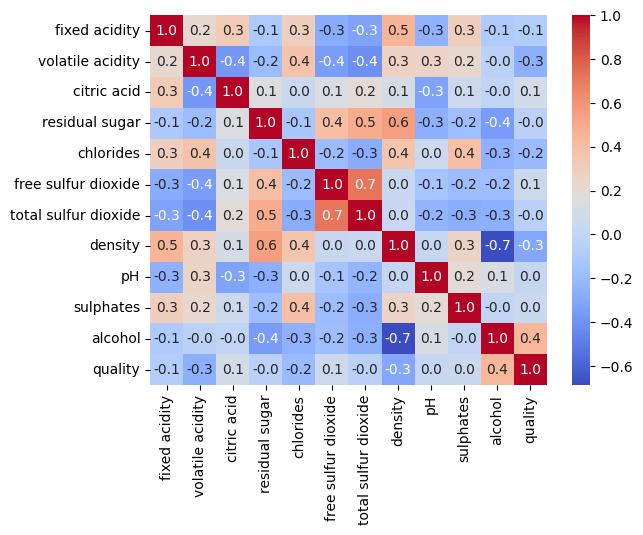

In [116]:
sns.heatmap(heatmap, annot=True, fmt='0.1f', cmap='coolwarm', xticklabels=wine_quality.columns, yticklabels=wine_quality.columns)


plt.show()


Pelo mapa de calor, podemos ver quais variáveis mais se correlacionam seja diretamente ou inversamente, para essa questão, pegaremos as que mais tem correlação entre si, sendo elas.


1.   Density x Alcohol | -0.7
2.   Free x Total sulfur dioxide | 0.7
3.   Density x Residual sugar | 0.6


Além disso, mostraremos as que tem mais correlação com qualidade.


1.   Alcohol | 0.4
2.   Density | -0.3
3.   Volatile Acidity | -0.3




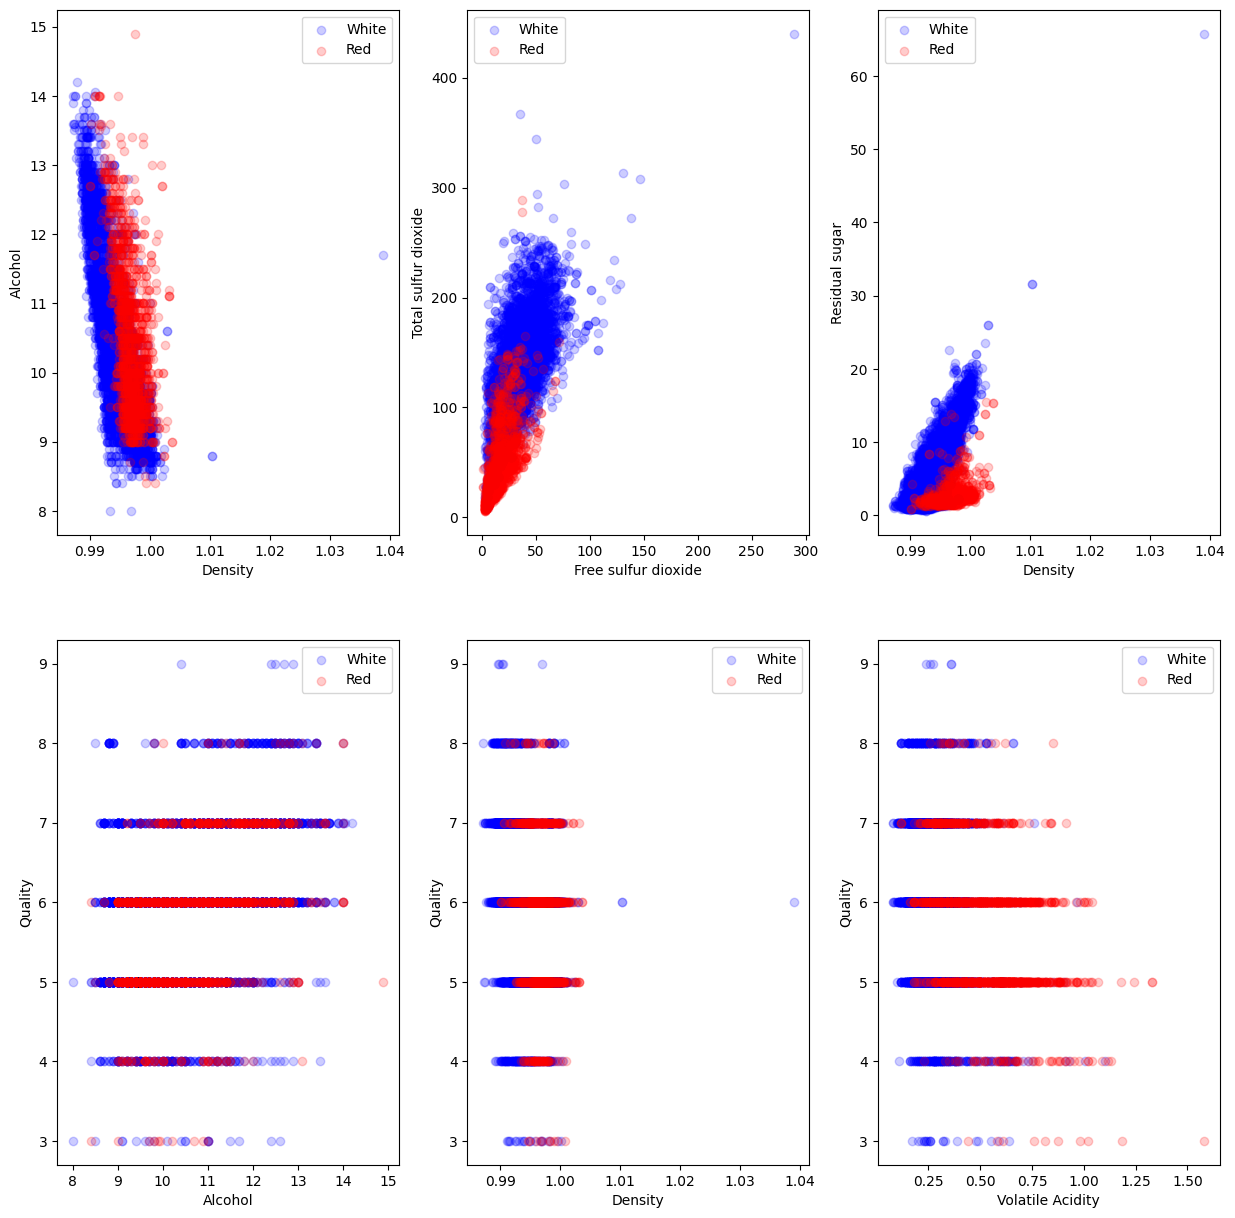

In [117]:
fig, ax = plt.subplots(2, 3)
fig.set_figwidth(15)
fig.set_figheight(15)


ax[0][0].scatter(white[7], white[10], color='blue', alpha=0.2, label='White')
ax[0][0].scatter(red[7], red[10], color='red', alpha=0.2, label='Red')
ax[0][0].set_xlabel('Density')
ax[0][0].set_ylabel('Alcohol')


ax[0][1].scatter(white[5], white[6], color='blue', alpha=0.2, label='White')
ax[0][1].scatter(red[5], red[6], color='red', alpha=0.2, label='Red')
ax[0][1].set_xlabel('Free sulfur dioxide')
ax[0][1].set_ylabel('Total sulfur dioxide')


ax[0][2].scatter(white[7], white[3], color='blue', alpha=0.2, label='White')
ax[0][2].scatter(red[7], red[3], color='red', alpha=0.2, label='Red')
ax[0][2].set_xlabel('Density')
ax[0][2].set_ylabel('Residual sugar')


# Relação com a qualidade

ax[1][0].scatter(white[10], white[11], color='blue', alpha=0.2, label='White')
ax[1][0].scatter(red[10], red[11], color='red', alpha=0.2, label='Red')
ax[1][0].set_xlabel('Alcohol')
ax[1][0].set_ylabel('Quality')


ax[1][1].scatter(white[7], white[11], color='blue', alpha=0.2, label='White')
ax[1][1].scatter(red[7], red[11], color='red', alpha=0.2, label='Red')
ax[1][1].set_xlabel('Density')
ax[1][1].set_ylabel('Quality')


ax[1][2].scatter(white[1], white[11], color='blue', alpha=0.2, label='White')
ax[1][2].scatter(red[1], red[11], color='red', alpha=0.2, label='Red')
ax[1][2].set_xlabel('Volatile Acidity')
ax[1][2].set_ylabel('Quality')


for i in range(0, 2):
  for j in range(0, 3):
    ax[i][j].legend(loc='best')

plt.show()

# 5º QUESTÃO

Perform an unconditional multi-variate analysis of the predictors. Specifically, you
must implement the principal components analysis (PCA) yourself without using
pre-made PCA functions or libraries. For visualisation purposes, retain only the
first two principal components (those associated with the two largest eigenvalues)
and plot the scatter plot of the projected observations. Again, for each projected
point (observation) you must use colours or symbols to indicate the associated class
label. [Remember to perform the necessary pre-processing of the data].



---

Faça uma analise multi-variada incodicional dos preditores. Especificamente, você deve implementar o PCA sem utilizar uma função já pronta. Para proposiotes de visualização, você deve usar as duas componentes principais e fazer um scatter plot com elas. Novamente, para cada ponto você deve usar cores ou simbolos que indicam a assoicação entre classes.

### Fazendo o PCA

#### Descobrindo os auto valores e auto vetores

---

Nesta etapa refaremos o mapa de calor, pois ele continha a qualidade que é um parametro de saída, portanto, não vale apena tentar analisar o grupo das observações com ele, pois em estudos futuros não poderemos usar ele como um preditor.

In [118]:
preditores = 11 #Remoção da qualidade

heatmap = np.empty((preditores, preditores))

for i in range(0, preditores):
  for j in range(0, preditores):
    heatmap[i][j] = cov(total_norm[i], total_norm[j])
    #print(heatmap[i][j])

In [119]:
lamb, v = eig(heatmap)
print("Auto valores")
print(lamb)

print("Auto vetores")
print(v)

Auto valores
[3.03033507 2.49420993 1.55658654 0.03283586 0.97070149 0.22773082
 0.33707593 0.71998573 0.6074052  0.50158749 0.5232393 ]
Auto vetores
[[ 2.38798897e-01  3.36354536e-01 -4.34301304e-01 -3.34679266e-01
  -1.64346214e-01 -2.81267685e-01  3.44056674e-01  1.47480376e-01
   2.04553713e-01  4.01235645e-01 -2.83079440e-01]
 [ 3.80757499e-01  1.17549716e-01  3.07259420e-01 -8.47718098e-02
  -2.12784888e-01  1.52176731e-01 -4.96932675e-01 -1.51455988e-01
   4.92143072e-01 -8.74350885e-02 -3.89159756e-01]
 [-1.52388438e-01  1.83299403e-01 -5.90569674e-01  1.10895136e-03
   2.64300312e-01  2.34463340e-01 -4.02688676e-01  1.55348697e-01
  -2.27633798e-01 -2.93412336e-01 -3.81285036e-01]
 [-3.45919930e-01  3.29914181e-01  1.64688429e-01 -4.49765078e-01
  -1.67443015e-01 -1.37277329e-03  1.08003195e-01  3.53361853e-01
   2.33477754e-01 -5.24872935e-01  2.17975536e-01]
 [ 2.90112586e-01  3.15257992e-01  1.66791047e-02 -4.34375867e-02
   2.44743855e-01 -1.96630217e-01  2.96443716e-01 -6

#### Selecionando os melhores

---

Os melhores são aqueles com maior auto valor, pois isso signifca que esse auto vetor carrega maior parte da variancia.

In [120]:
sum = 0

for i in lamb:
  sum += i

lamb_percent = []

for i in lamb:
  lamb_percent.append(i/sum)

for i in range(0, len(lamb_percent)):
  print(f"{i} - {lamb_percent[i] * 100:.1f}%")

0 - 27.5%
1 - 22.7%
2 - 14.1%
3 - 0.3%
4 - 8.8%
5 - 2.1%
6 - 3.1%
7 - 6.5%
8 - 5.5%
9 - 4.6%
10 - 4.8%


#### Projetando os valores em cima dos auto vetores com maior relevancia

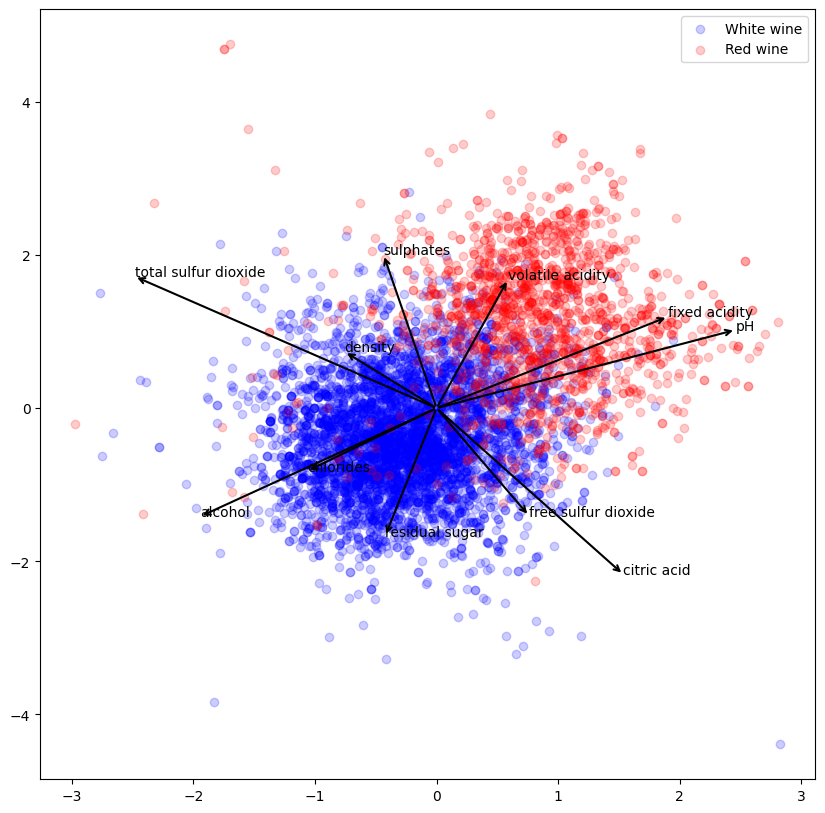

In [121]:
plt.figure(figsize=(10,10))



new_white = white_norm.transpose()
new_red = red_norm.transpose()

x_white = []
y_white = []

x_red = []
y_red = []


#White
for w_v in new_white:
  y_value = 0
  x_value = 0

  for i in range(0, preditores):
    y_value += w_v[i]*v[0][i]
    x_value += w_v[i]*v[1][i]

  x_white.append(x_value)
  y_white.append(y_value)


#Red
for r_v in new_red:
  y_value = 0
  x_value = 0

  for j in range(0, preditores):
    y_value += r_v[j]*v[0][j]
    x_value += r_v[j]*v[1][j]

  x_red.append(x_value)
  y_red.append(y_value)


#Setas indicando os preditores.
arrow_preditores = []

for i in range(0, preditores):
  arrow = []

  for j in range(0, preditores):
    arrow.append(1 if i == j else 0)

  arrow_preditores.append(arrow)

x_preditores = []
y_preditores = []
const = 5

for p_v in arrow_preditores:
  y_value = 0
  x_value = 0

  for j in range(0, preditores):
    y_value += p_v[j]*v[0][j]
    x_value += p_v[j]*v[1][j]

  x_preditores.append(x_value)
  y_preditores.append(y_value)

plt.scatter(x_white, y_white, color= 'blue', label='White wine', alpha = 0.2)
plt.scatter(x_red, y_red, color= 'red',label='Red wine', alpha = 0.2)

for i in range(0, preditores):

    plt.annotate(
        '',
        xy=(const*x_preditores[i], const*y_preditores[i]),
        xytext=(0, 0),
        arrowprops=dict(
            arrowstyle='->',
            linewidth=1.5
        ),
        zorder=10
    )

    plt.text(
        const*x_preditores[i],
        const*y_preditores[i],
        wine_quality.columns[i],
        zorder=11
    )




plt.legend(loc='best')

plt.show()

## Importancia de cada preditores na PCA

In [122]:
PCA_preditores = []
for i in range(0, preditores):
  tamanho = np.sqrt((x_preditores[i]**2) + (y_preditores[i]**2))
  PCA_preditores.append([tamanho, x_preditores[i], y_preditores[i], wine_quality.columns[i]])


PCA_preditores = np.array(PCA_preditores).reshape((preditores, 4))

PCA_preditores = PCA_preditores[PCA_preditores[:,0].argsort()[::-1]]

for i in range(0, preditores):
  print(f'Tamanho: {np.float64(PCA_preditores[i][0]):.2f} - Vetor: ({np.float64(PCA_preditores[i][1]):.2f},{np.float64(PCA_preditores[i][2]):.2f}) - {PCA_preditores[i][3]}')



Tamanho: 0.60 - Vetor: (-0.50,0.34) - total sulfur dioxide
Tamanho: 0.53 - Vetor: (0.49,0.20) - pH
Tamanho: 0.53 - Vetor: (0.31,-0.43) - citric acid
Tamanho: 0.48 - Vetor: (-0.39,-0.28) - alcohol
Tamanho: 0.45 - Vetor: (0.38,0.24) - fixed acidity
Tamanho: 0.41 - Vetor: (-0.09,0.40) - sulphates
Tamanho: 0.36 - Vetor: (0.12,0.34) - volatile acidity
Tamanho: 0.35 - Vetor: (-0.08,-0.33) - residual sugar
Tamanho: 0.32 - Vetor: (0.15,-0.28) - free sulfur dioxide
Tamanho: 0.27 - Vetor: (-0.21,-0.16) - chlorides
Tamanho: 0.21 - Vetor: (-0.15,0.15) - density
